<a href="https://colab.research.google.com/github/yunirajagukguk/Analisis-dan-Visualisasi-Data_Tugas-4/blob/main/Customer_Personality_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Preprocessing**

Import Library

In [2]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

Upload dataset

In [3]:
df = pd.read_csv('marketing_campaign.csv', sep='\t')
print(df.head())

     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  AcceptedCmp3  \
0  04-09-2012       58       635  ...                  7             0   
1  08-03-2014       38        11  ...                  5             0   
2  21-08-2013       26       426  ...                  4             0   
3  10-02-2014       26        11  ...                  6             0   
4  19-01-2014       94       173  ...                  5             0   

   AcceptedCmp4  AcceptedCmp5  AcceptedCmp1  AcceptedCmp2  Complain  \
0             0

In [4]:
print("Ukuran dataset sebelum cleansing:", df.shape)

Ukuran dataset sebelum cleansing: (2240, 29)


Cek Jumlah missing value

In [5]:
print("\nJumlah missing value per kolom:")
print(df.isnull().sum())


Jumlah missing value per kolom:
ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64


Menghapus baris yang memiliki nilai kosong pada Income

In [6]:
df_clean = df.dropna(subset=['Income'])

Cek data setelah di cleansing

In [7]:
print("\nUkuran dataset setelah cleansing:", df_clean.shape)


Ukuran dataset setelah cleansing: (2216, 29)


Cek missing value setelah di hapus

In [8]:
print("\nMissing value Income setelah cleansing:")
print(df_clean['Income'].isnull().sum())


Missing value Income setelah cleansing:
0


Menyimpan data cleaning

In [9]:
df_clean.to_csv('marketing_campaign_clean.csv', index=False)
print("Dataset berhasil disimpan.")

Dataset berhasil disimpan.


**Feature Engineering**

Memilih atribut yang digunakan

In [10]:
# Umur pelanggan
df['Age'] = 2026 - df['Year_Birth']

# Total pengeluaran pelanggan
df['TotalSpend'] = (
    df['MntWines']
    + df['MntFruits']
    + df['MntMeatProducts']
    + df['MntFishProducts']
    + df['MntSweetProducts']
    + df['MntGoldProds']
)

# Jumlah anak
df['Children'] = df['Kidhome'] + df['Teenhome']

Memilih Fitur Untuk Clustering

In [11]:
features = [
    'Income',
    'Age',
    'Recency',
    'TotalSpend',
    'Children',
    'NumWebPurchases',
    'NumCatalogPurchases',
    'NumStorePurchases',
    'NumWebVisitsMonth'
]

X = df[features]

Standardisasi Data

In [12]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(2240, 9)


Menentukan Jumlah Komponen PCA

In [14]:
pca = PCA()

# Drop rows with NaN values from X_scaled before applying PCA
X_scaled_cleaned = X_scaled[~np.isnan(X_scaled).any(axis=1)]
X_pca = pca.fit_transform(X_scaled_cleaned)

explained_variance = pca.explained_variance_ratio_

print(explained_variance)

[0.4348776  0.12814282 0.11236202 0.10530156 0.07032871 0.0531849
 0.04291063 0.03432129 0.01857047]


Visualisasi Explained Variance

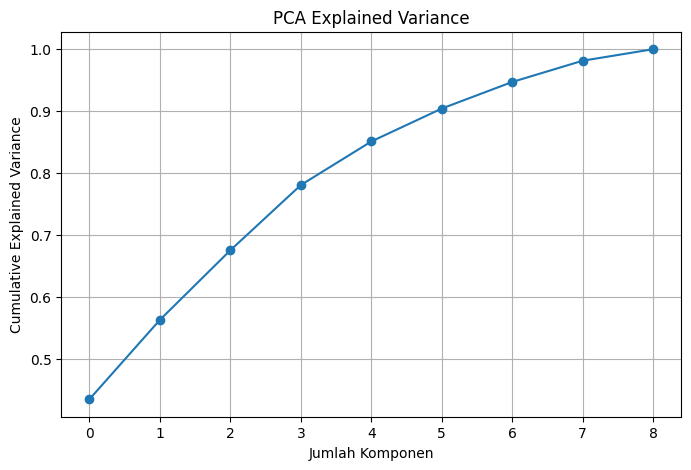

In [15]:
plt.figure(figsize=(8,5))

plt.plot(
    np.cumsum(explained_variance),
    marker='o'
)

plt.xlabel('Jumlah Komponen')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.grid(True)

plt.show()

**Melakukan PCA(Dimension Reduction)**

In [17]:
pca = PCA(n_components=4)

X_reduced = pca.fit_transform(X_scaled_cleaned)

print("Shape sebelum PCA :", X_scaled_cleaned.shape)
print("Shape sesudah PCA :", X_reduced.shape)

Shape sebelum PCA : (2216, 9)
Shape sesudah PCA : (2216, 4)


Menampilkan Variansi yang Dipertahankan

In [20]:
print(
    "Total Explained Variance:",
    np.sum(pca.explained_variance_ratio_)
)

Total Explained Variance: 0.7806839959508017


**Model** **Clustering**

Metode Elbow untuk menentukan jumlah cluster yang optimal

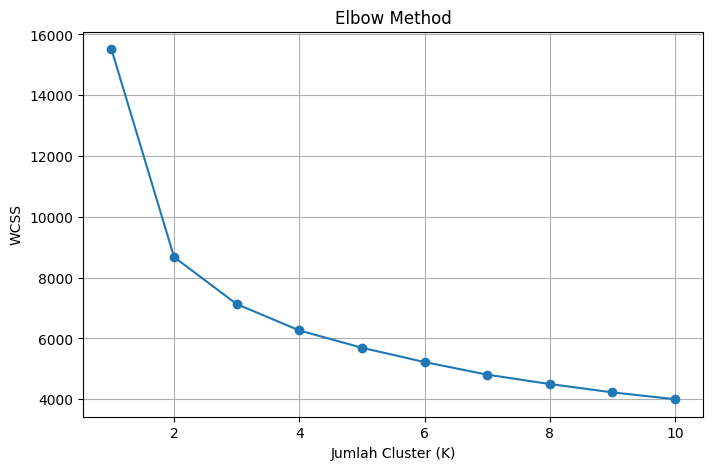

In [21]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1,11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_reduced)
    wcss.append(kmeans.inertia_)

# Visualisasi Elbow
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.grid(True)
plt.show()

Silhouette Score untuk memastikan bahwa K=3 sudah optimal

In [22]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_reduced)

    score = silhouette_score(X_reduced, labels)

    print(f"K={k} -> Silhouette Score={score:.4f}")

K=2 -> Silhouette Score=0.3844
K=3 -> Silhouette Score=0.3100
K=4 -> Silhouette Score=0.2374
K=5 -> Silhouette Score=0.2366
K=6 -> Silhouette Score=0.2271
K=7 -> Silhouette Score=0.2226
K=8 -> Silhouette Score=0.2250
K=9 -> Silhouette Score=0.2292
K=10 -> Silhouette Score=0.2179


In [26]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

df_clean['Cluster'] = kmeans.fit_predict(X_reduced)

print(df_clean['Cluster'].value_counts())

Cluster
0    1233
1     983
Name: count, dtype: int64


**Estimasi segmentasi pelanggan (customer Segmentation)**

In [30]:
segmentasi = df_clean.groupby('Cluster')[[
    'Income',
    'TotalSpend',
    'Age',
    'Children',
    'Recency'
]].mean().round(2)

print(segmentasi)

           Income  TotalSpend    Age  Children  Recency
Cluster                                                
0        37057.54      157.97  55.45      1.27    48.61
1        71300.06     1170.39  59.35      0.55    49.52
